In [11]:
import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run


run = open_run("20260930173346")

#20260929193050
#20260929211655

run.info()

Run_ID,Sim_Type,Status,Directory,Trajectory,HDF5,Frame_Count
20260930173346,Expanded_FCC,Complete,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346/trajectory.gsd,/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346/run.hdf5,201


Run_ID,Run_Signature,N_Cells,Nsteps,Current_Nstep,ElapsedTime,StartTime,EndTime,Last_Update_Time,Sim_Type,Status,Stop_Reason,Status_Message,Notes
20260930173346,c5dec360bf8c376a65bd6f1d0d324f3eb7e68a95f60f7b1e73cdc77dd51a0b33,20,2000000,2000000,1550.773593,2026-09-30 17:33:46.484516,2026-09-30 18:01:54.862015,2026-09-30 18:01:54.862015,Expanded_FCC,Complete,None,None,Expanded FCC: center length 3L; 2 original box length(s) added per side; side density divided by 25; interface Linear with width 8.


{'Run_ID': '20260930173346',
 'Sim_Type': 'Expanded_FCC',
 'Status': 'Complete',
 'Directory': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346',
 'Trajectory': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346/trajectory.gsd',
 'HDF5': '/exp/e961/data/MDsims-data/pnichols/SQL/Expanded_FCC/20260930173346/run.hdf5',
 'Frame_Count': 201}

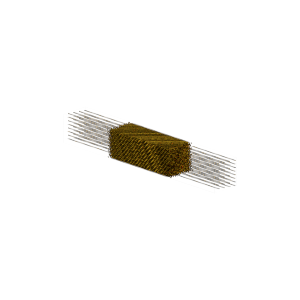

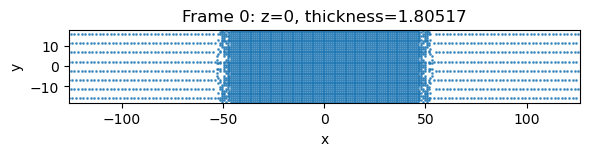

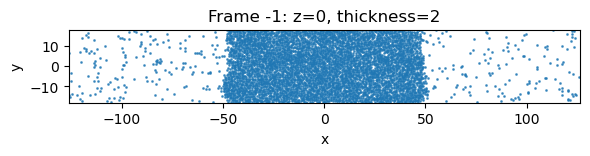

In [12]:
# 3D views
run.render(frame=0)
#run.render(frame=-1)
#run.render_movie()

# XY slices
run.xy_slice(frame=0)
run.xy_slice(frame=-1, z=0, thickness=2.0);
#run.xy_slice(frames=[0, 10, 20, -1])
run.xy_slice_movie(frame_step=1);

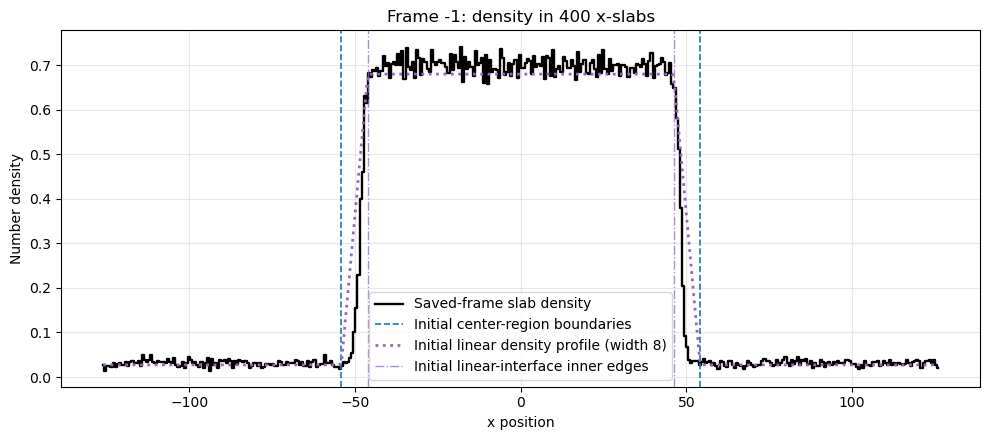

In [13]:
figure, density_slices = run.plot_density_profile(
    frame=-1,
    num_slices=400,
)

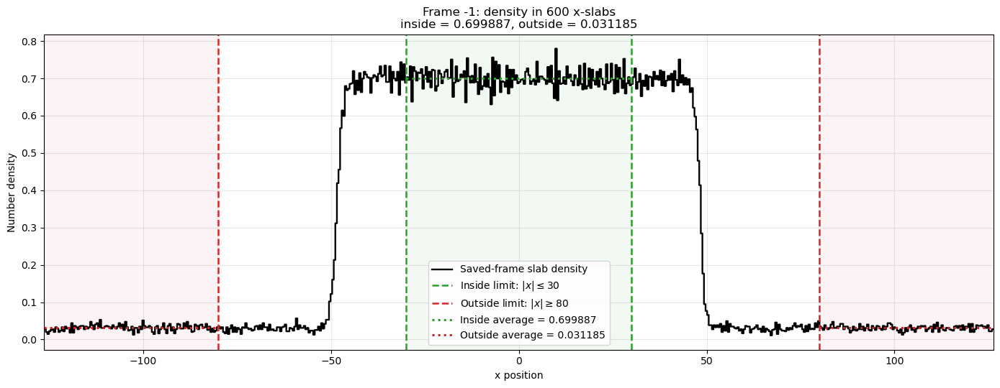

,region,selection,particle_count,volume,average_number_density
0,inside,|x| <= 30,54736,78206.937980,0.699887
1,outside,|x| >= 80,3769,120859.926673,0.031185


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- manually tune these ----------------
frame = -1
num_slices = 600

inside_half_width = 30.0   # Inside:  |x| <= this distance from center
outside_start = 80.0      # Outside: |x| >= this distance from center
# -----------------------------------------------------

saved = run.load_frame(frame)
box = np.asarray(saved.configuration.box, dtype=float)
Lx, Ly, Lz = box[:3]

if not (0 < inside_half_width < outside_start < Lx / 2):
    raise ValueError(
        f"Require 0 < inside_half_width < outside_start < Lx/2 "
        f"(currently Lx/2 = {Lx / 2:.3f})"
    )

# Wrap x positions into [-Lx/2, Lx/2).
x = np.asarray(saved.particles.position[:, 0], dtype=float)
x = (x + Lx / 2) % Lx - Lx / 2
abs_x = np.abs(x)

inside_mask = abs_x <= inside_half_width
outside_mask = abs_x >= outside_start

cross_section = Ly * Lz
inside_volume = 2.0 * inside_half_width * cross_section
outside_volume = (Lx - 2.0 * outside_start) * cross_section

inside_density = inside_mask.sum() / inside_volume
outside_density = outside_mask.sum() / outside_volume

# Density slices used for the profile.
density_slices = run.density_profile(
    frame=frame,
    num_slices=num_slices,
    axis="x",
)

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.step(
    density_slices["x_center"].to_numpy(),
    density_slices["number_density"].to_numpy(),
    where="mid",
    color="black",
    linewidth=1.7,
    label="Saved-frame slab density",
)

# Boundaries of the selected inside region.
ax.axvline(
    -inside_half_width,
    color="tab:green",
    linestyle="--",
    linewidth=1.8,
    label=rf"Inside limit: $|x|\leq {inside_half_width:g}$",
)
ax.axvline(
    inside_half_width,
    color="tab:green",
    linestyle="--",
    linewidth=1.8,
)

# Boundaries beyond which particles belong to the outside region.
ax.axvline(
    -outside_start,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
    label=rf"Outside limit: $|x|\geq {outside_start:g}$",
)
ax.axvline(
    outside_start,
    color="tab:red",
    linestyle="--",
    linewidth=1.8,
)

# Show the measured averages over their respective spatial regions.
ax.hlines(
    inside_density,
    -inside_half_width,
    inside_half_width,
    color="tab:green",
    linestyle=":",
    linewidth=2.2,
    label=f"Inside average = {inside_density:.6f}",
)
ax.hlines(
    outside_density,
    -Lx / 2,
    -outside_start,
    color="tab:red",
    linestyle=":",
    linewidth=2.2,
    label=f"Outside average = {outside_density:.6f}",
)
ax.hlines(
    outside_density,
    outside_start,
    Lx / 2,
    color="tab:red",
    linestyle=":",
    linewidth=2.2,
)

ax.axvspan(
    -inside_half_width,
    inside_half_width,
    color="tab:green",
    alpha=0.06,
)
ax.axvspan(-Lx / 2, -outside_start, color="tab:red", alpha=0.05)
ax.axvspan(outside_start, Lx / 2, color="tab:red", alpha=0.05)

ax.set_xlim(-Lx / 2, Lx / 2)
ax.set_xlabel("x position")
ax.set_ylabel("Number density")
ax.set_title(
    f"Frame {frame}: density in {num_slices} x-slabs\n"
    f"inside = {inside_density:.6f}, outside = {outside_density:.6f}"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

density_summary = pd.DataFrame(
    {
        "region": ["inside", "outside"],
        "selection": [
            f"|x| <= {inside_half_width:g}",
            f"|x| >= {outside_start:g}",
        ],
        "particle_count": [
            int(inside_mask.sum()),
            int(outside_mask.sum()),
        ],
        "volume": [inside_volume, outside_volume],
        "average_number_density": [
            inside_density,
            outside_density,
        ],
    }
)

display(density_summary)

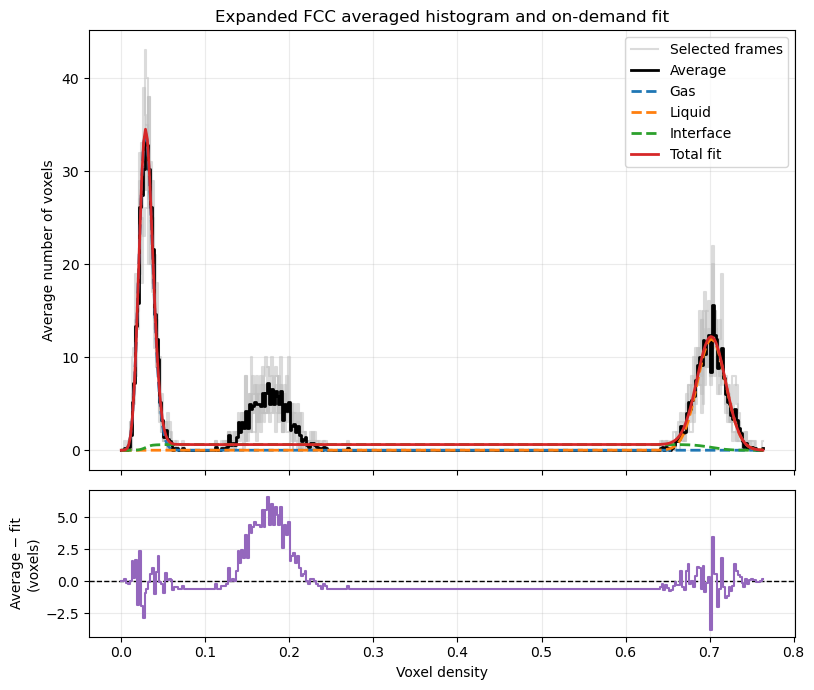

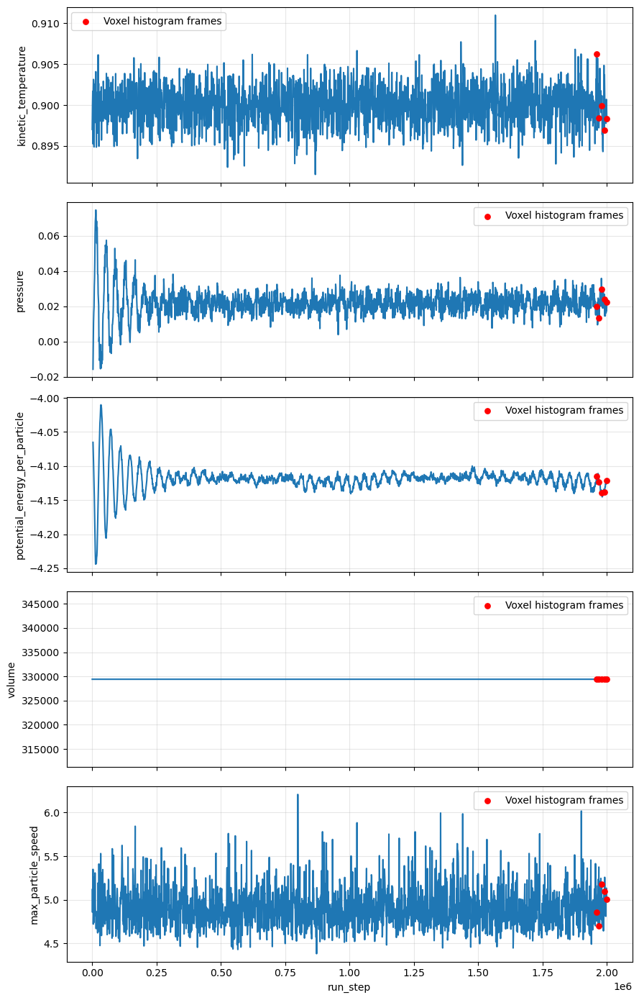

In [15]:
# Phase fit and logs
run.plot_phase_fit();
run.plot_logs();

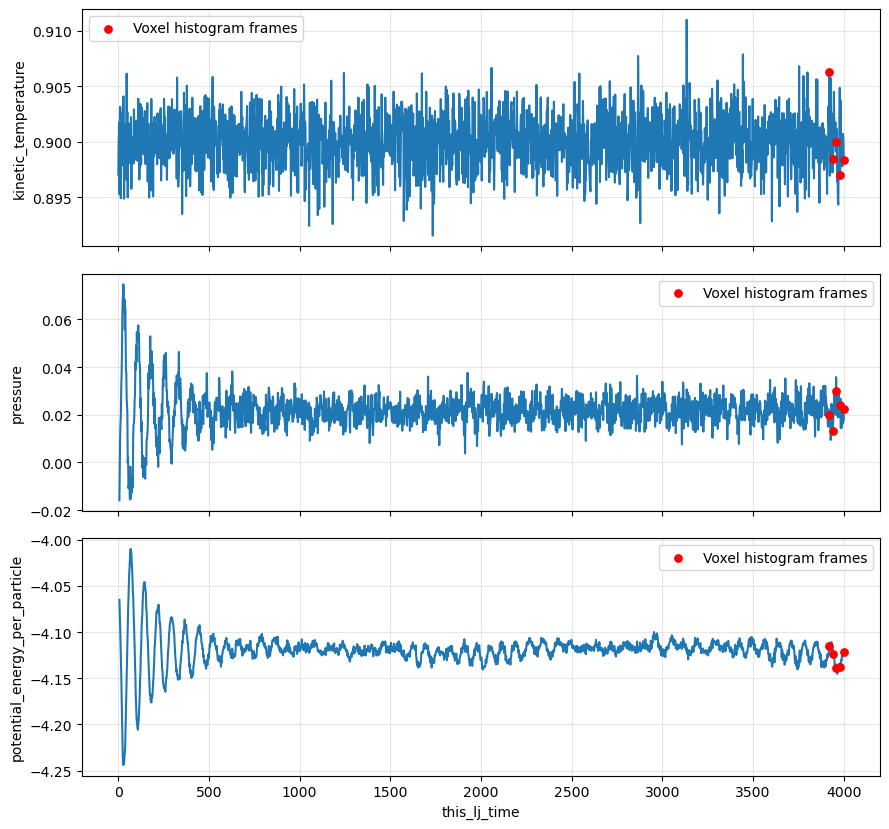

In [16]:
run.plot_logs(
    [
        "kinetic_temperature",
        "pressure",
        "potential_energy_per_particle",
        #"volume",
        #"density",
        #"max_particle_speed",
    ],
    x="this_lj_time",
);

#x="frame"
#x="hoomd_timestep"
#x="run_step"
#x="this_lj_time"
#x="cumulative_lj_time"

In [17]:
logs = run.logs_dataframe()
metadata = run.metadata()
frame_table = run.frame_table()

for field, value in metadata.items():
    print(f"{field}: {value}")

mdsims/analysis/com_recenter/COM_Before_Recenter: [[-1.05320269e-13  1.43361174e-14 -3.59656504e-15]
 [-3.00814307e-14  3.16000101e-15 -3.86675573e-16]
 [ 1.30018230e-13  4.76300558e-15 -1.71363131e-15]
 [-3.20364781e-13  1.17600007e-15 -1.30243062e-15]
 [ 2.91622399e-13 -3.01383923e-18 -5.11991008e-15]
 [-5.68749135e-14  3.18012780e-15 -1.98370898e-15]
 [ 2.60882444e-14  1.73820352e-15  2.77454039e-15]
 [ 2.60320514e-13 -1.83461812e-15 -6.80826281e-15]
 [-1.05270842e-13  5.80440947e-15  8.89082571e-18]
 [-1.80713718e-13  1.28623500e-14 -5.96740167e-15]
 [ 9.74063796e-14 -1.21921287e-14  4.80195004e-15]
 [-1.52751242e-13  4.66483919e-15  5.36915458e-16]
 [-8.15573526e-14  7.57102784e-15 -2.44972387e-15]
 [ 2.70226928e-13 -7.63141765e-16 -6.44961594e-16]
 [ 4.05805917e-15  1.46446969e-14 -8.67156891e-16]
 [-5.53212794e-15 -1.44265137e-14 -1.58463899e-15]
 [ 1.83472737e-13  1.01171946e-14 -7.12023284e-15]
 [-2.20432276e-13  4.29057687e-15  4.26488389e-15]
 [-1.57375451e-13 -2.46739438e-1